In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


### Ok, let's do it via pytorch

In [3]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### Transformation

In [4]:
transformation = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [6]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
    download=True
)

In [7]:
test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
    download=True
)

In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [9]:
for img, label in train_dataloader:
    print(f"Label: {label}, shape: {label.shape}")
    print(f"img: {img}, shape: {img.shape}")
    break

Label: tensor([1, 4, 4, 7, 8, 3, 1, 3, 1, 2, 1, 1, 8, 8, 3, 7, 0, 4, 1, 3, 1, 5, 5, 8,
        5, 1, 5, 4, 3, 1, 5, 7, 4, 8, 9, 2, 9, 6, 4, 6, 9, 9, 7, 4, 4, 1, 5, 5,
        3, 6, 4, 1, 6, 4, 9, 4, 7, 5, 9, 0, 2, 8, 7, 6, 3, 6, 0, 1, 5, 3, 2, 6,
        5, 4, 9, 8, 1, 7, 4, 6, 6, 8, 4, 5, 1, 8, 8, 4, 9, 1, 9, 4, 4, 3, 1, 0,
        8, 5, 0, 9, 0, 7, 2, 3, 5, 3, 4, 6, 2, 7, 1, 3, 9, 0, 4, 2, 8, 2, 4, 9,
        5, 0, 6, 9, 4, 4, 9, 3]), shape: torch.Size([128])
img: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), shape: torch.Size([128, 784])


### Let's Build the encoder

In [10]:
class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.layer1 = nn.Linear(784, 400)
        self.layer2 = nn.Linear(400, 100)
        self.mu_head = nn.Linear(100, latent_dim)
        self.log_var_head = nn.Linear(100, latent_dim)
        
    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        mu = self.mu_head(x)
        log_var = self.log_var_head(x)
        return mu, log_var

### Reparametarization Trick

In [11]:
def reparametarization(mu, log_var):
    sigma = torch.exp(0.5 * log_var)
    epsilon = torch.randn_like(mu)
    return mu + sigma * epsilon

### Let's Build the Decoder

In [12]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.layer1 = nn.Linear(latent_dim, 100)
        self.layer2 = nn.Linear(100, 400)
        self.layer3 = nn.Linear(400, 784)
        
    def forward(self, z):
        z = self.layer1(z)
        z = F.relu(z)
        z = self.layer2(z)
        z = F.relu(z)
        z = self.layer3(z)
        x = torch.sigmoid(z)
        return x

### VAE neural network

In [13]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparametarization(mu=mu, log_var=log_var)
        x_constructed = self.decoder(z)
        return x_constructed, mu, log_var

### Loss Function

In [14]:
def vae_loss(x_constructed, x_original, mu, log_var):
    # reconstruction error
    recons_err = F.binary_cross_entropy(x_constructed, x_original, reduction='sum')
    # Kl divergence regularizer
    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
    loss = (recons_err + kl_loss)/x_original.size(0)
    return loss

### Training Loop

In [29]:
latent_dim = 20
num_epochs = 50
model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [30]:
for epoch in range(num_epochs):
    total_loss = 0
    for image, _ in train_dataloader:
        x_contructed, mu, log_var = model.forward(image)
        loss = vae_loss(x_contructed, image, mu, log_var)
        total_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = total_loss/len(train_dataloader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss.item():.2f}")

Epoch 1, Loss: 180.18
Epoch 2, Loss: 133.09
Epoch 3, Loss: 120.39
Epoch 4, Loss: 115.13
Epoch 5, Loss: 112.13
Epoch 6, Loss: 110.04
Epoch 7, Loss: 108.52
Epoch 8, Loss: 107.43
Epoch 9, Loss: 106.46
Epoch 10, Loss: 105.76
Epoch 11, Loss: 105.13
Epoch 12, Loss: 104.56
Epoch 13, Loss: 104.05
Epoch 14, Loss: 103.72
Epoch 15, Loss: 103.31
Epoch 16, Loss: 103.00
Epoch 17, Loss: 102.68
Epoch 18, Loss: 102.39
Epoch 19, Loss: 102.12
Epoch 20, Loss: 101.90
Epoch 21, Loss: 101.67
Epoch 22, Loss: 101.49
Epoch 23, Loss: 101.29
Epoch 24, Loss: 101.11
Epoch 25, Loss: 101.00
Epoch 26, Loss: 100.85
Epoch 27, Loss: 100.72
Epoch 28, Loss: 100.55
Epoch 29, Loss: 100.42
Epoch 30, Loss: 100.29
Epoch 31, Loss: 100.16
Epoch 32, Loss: 100.07
Epoch 33, Loss: 99.96
Epoch 34, Loss: 99.82
Epoch 35, Loss: 99.78
Epoch 36, Loss: 99.64
Epoch 37, Loss: 99.59
Epoch 38, Loss: 99.48
Epoch 39, Loss: 99.43
Epoch 40, Loss: 99.28
Epoch 41, Loss: 99.30
Epoch 42, Loss: 99.19
Epoch 43, Loss: 99.12
Epoch 44, Loss: 98.98
Epoch 45,

### Eval mode

In [31]:
with torch.no_grad():
    images, _ = next(iter(test_dataloader))
    x_contructed, mu, log_var = model(image)

In [32]:
image.shape

torch.Size([96, 784])

In [33]:
image = images[0].view(28, 28)
recon = x_contructed[0].view(28,28)

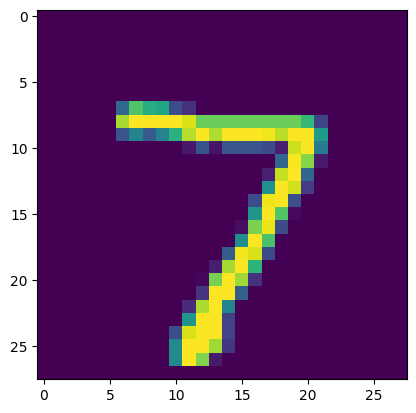

In [34]:
plt.imshow(image)

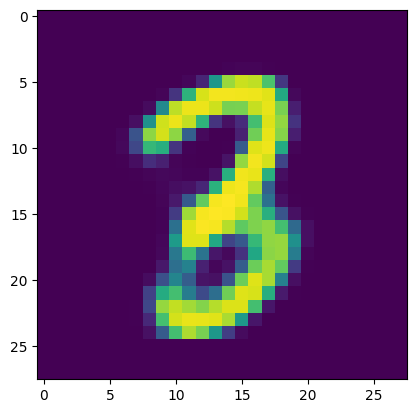

In [35]:
plt.imshow(recon)

### Generating new digits

In [68]:
with torch.no_grad():
    z = torch.randn(16, latent_dim)
    generated = model.decoder(z)

In [69]:
generated.shape

torch.Size([16, 784])

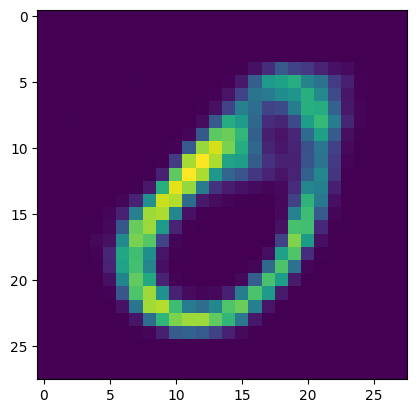

In [70]:
plt.imshow(generated[0].view(28,28))

## When Latent_dim = 2

In [71]:
# figs, axes = plt.subplots(4, 4, figsize=(8, 8))
# for i in range(4):
#     for j in range(4):
#         axes[i][j].imshow(generated[i+j].view(28, 28))
#         axes[i][j].axis('off')

## When Latent_dim = 8

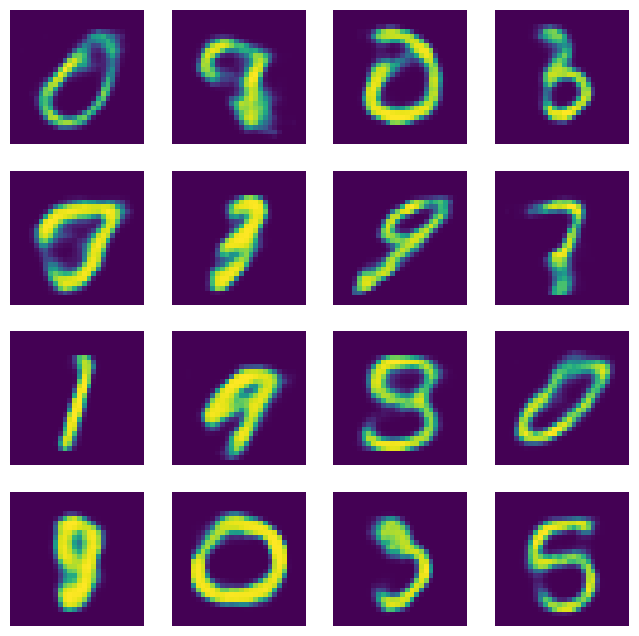

In [72]:
figs, axes = plt.subplots(4, 4, figsize=(8, 8))
count = 0
for i in range(4):
    for j in range(4):
        axes[i][j].imshow(generated[count].view(28, 28))
        axes[i][j].axis('off')
        count+=1

In [ ]:
all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        mu, log_var = model.encoder(images)
        all_mu.append(mu)
        all_labels.append(labels)

In [27]:
all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

## For latent_space = 2

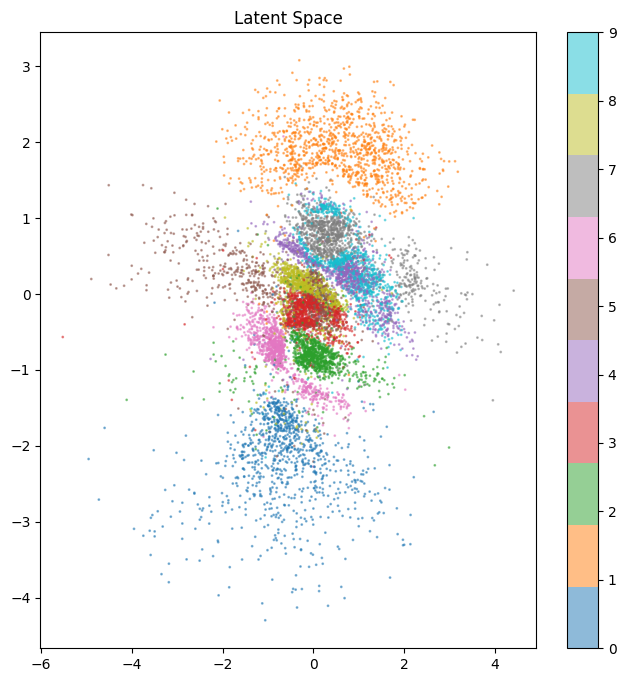

In [61]:
plt.figure(figsize=(8,8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                      c=all_labels,
                      cmap='tab10',
                      alpha=0.5,
                      s=1)
plt.colorbar(scatter)
plt.title("Latent Space")
plt.show()

## For latent_space = 3

In [28]:
# creating a dataframe
df = pd.DataFrame({
    "z1": all_mu[:, 0],
    'z2': all_mu[:, 1],
    'z3': all_mu[:, 2],
    'digit': all_labels.astype(str)
})

In [29]:
import plotly.express as px
fig = px.scatter_3d(df, x='z1', y='z2', z='z3',
                    color='digit',
                    title='Latent Space (3D)',
                    opacity=0.5,
                    size_max=2)

fig.update_traces(marker=dict(size=2))
fig.show()

# Save the model

In [31]:
## Save the parameters
torch.save(model.state_dict(), str(project_root / "data" / "vae_model_3.pth"))